In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [4]:
df.shape

(1599, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


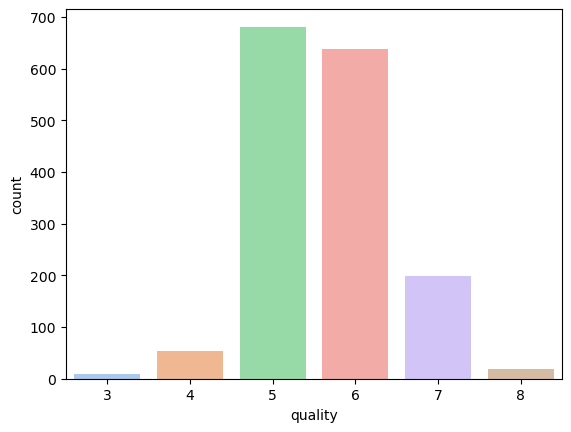

In [6]:
sns.countplot(x = df['quality'], palette= 'pastel')
plt.show()

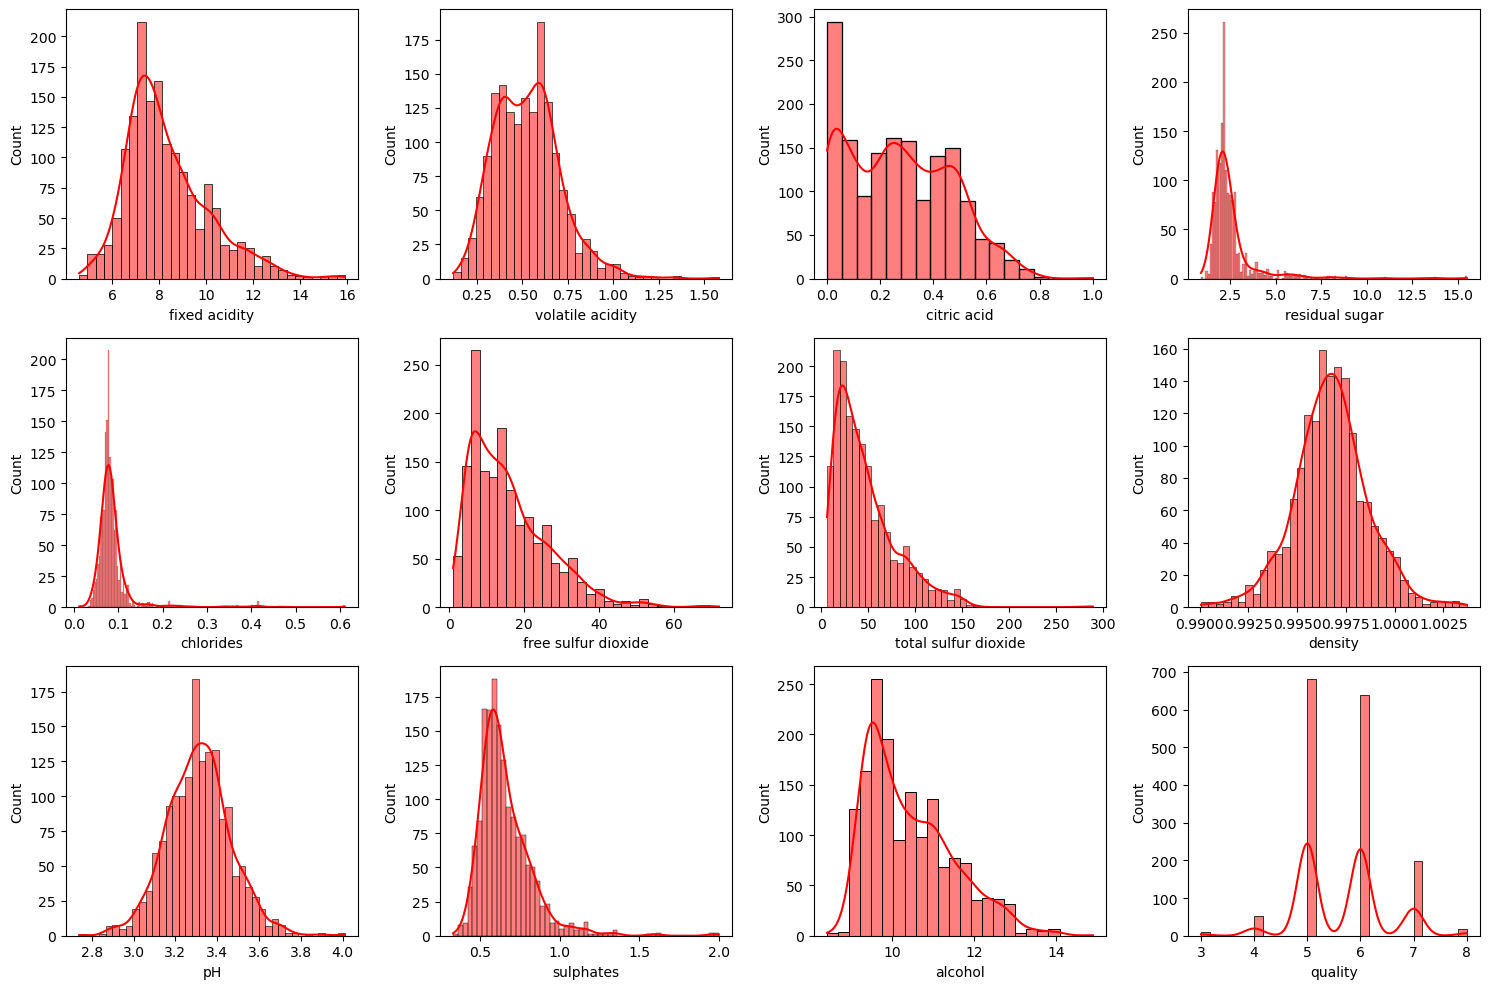

In [7]:
Num_Fea = df.select_dtypes(exclude = 'object')
# distribution  plot of each as subject
fig,axes = plt.subplots(nrows = 3, ncols = 4, figsize = (15,10))
k = 0
for i in range(3):
    for j in range(4):
            sns.histplot(df[df.columns[k]], ax = axes[i][j], color = 'red', kde= True) 
            k += 1
plt.tight_layout()
plt.show()

In [8]:

# apply log transform on features
df["residual sugar"]=np.log(df["residual sugar"])
df["chlorides"]=np.log(df["chlorides"])
df["free sulfur dioxide"]=np.log(df["free sulfur dioxide"])
df["total sulfur dioxide"]=np.log(df["total sulfur dioxide"])
df["sulphates"]=np.log(df["sulphates"])




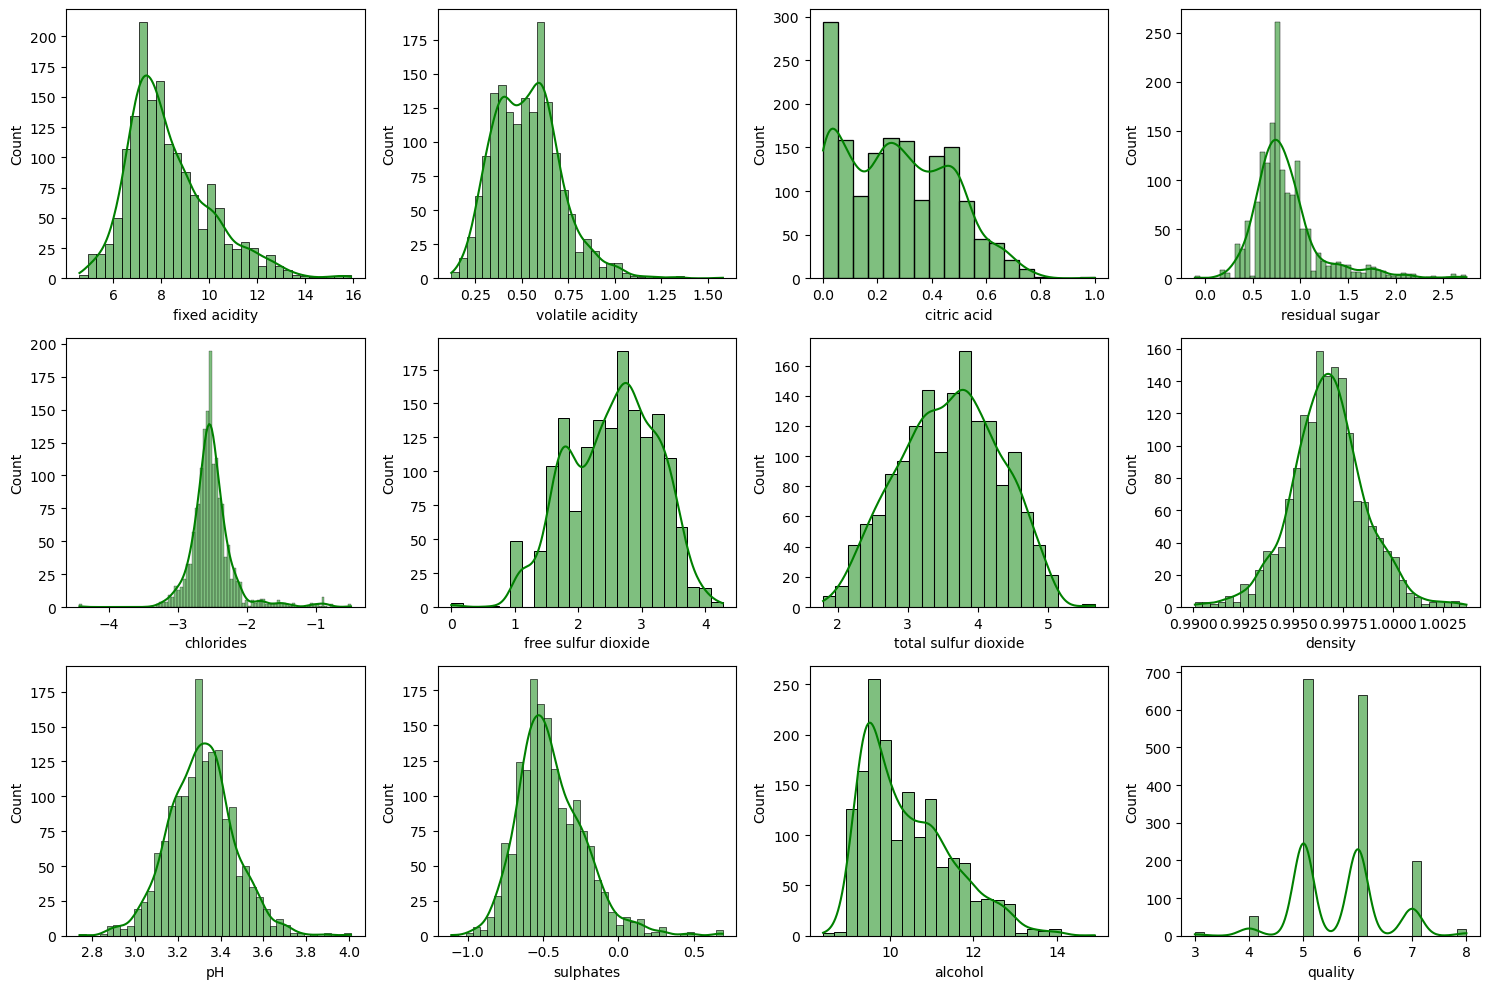

In [9]:
Num_Fea = df.select_dtypes(exclude = 'object')
# distribution  plot of each as subject
fig,axes = plt.subplots(nrows = 3, ncols = 4, figsize = (15,10))
k = 0
for i in range(3):
    for j in range(4):
            sns.histplot(df[df.columns[k]], ax = axes[i][j], color = 'green', kde= True) 
            k += 1
plt.tight_layout()
plt.show()

In [10]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [11]:
# look at the duplicated values
df.duplicated().sum()

np.int64(240)

In [12]:
# drop the duplicated values
df.drop_duplicates()
df.duplicated().sum()

np.int64(240)

In [13]:
# independent features
x = df.drop('quality',axis='columns')
x.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,0.641854,-2.577022,2.397895,3.526361,0.9978,3.51,-0.579818,9.4
1,7.8,0.88,0.00,0.955511,-2.322788,3.218876,4.204693,0.9968,3.20,-0.385662,9.8
2,7.8,0.76,0.04,0.832909,-2.385967,2.708050,3.988984,0.9970,3.26,-0.430783,9.8
3,11.2,0.28,0.56,0.641854,-2.590267,2.833213,4.094345,0.9980,3.16,-0.544727,9.8
4,7.4,0.70,0.00,0.641854,-2.577022,2.397895,3.526361,0.9978,3.51,-0.579818,9.4


In [14]:
# dependent features
y = df['quality']
y.head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

In [15]:
y.value_counts

<bound method IndexOpsMixin.value_counts of 0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64>

In [16]:
!pip install imblearn

In [17]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=4)
# transform the dataset
x, y = oversample.fit_resample(x.fillna(0), y)

In [18]:
y.value_counts()

quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64

In [19]:
x.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000,4086.000000
mean,8.296178,0.587508,0.261580,0.874235,-2.512664,2.348702,3.324147,0.996476,3.332329,-0.451671,10.735830
std,1.680881,0.252482,0.204858,0.351391,0.313334,0.671079,0.691058,0.001896,0.151822,0.217927,1.172070
min,4.600000,0.120000,0.000000,-0.105361,-4.422849,0.000000,1.791759,0.990070,2.740000,-1.108663,8.400000
25%,7.131749,0.390000,0.050000,0.641854,-2.668835,1.791759,2.715430,0.995288,3.227767,-0.616186,9.800000
50%,7.900000,0.540208,0.250000,0.788457,-2.551046,2.389820,3.286169,0.996491,3.327538,-0.472462,10.626844
75%,9.300000,0.730513,0.440800,1.001939,-2.411749,2.848667,3.854166,0.997655,3.430983,-0.300372,11.500000
max,15.900000,1.580000,1.000000,2.740840,-0.492658,4.276666,5.666427,1.003690,4.010000,0.693147,14.900000


In [20]:
# feature scaling by min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x)
x = scaler.transform(x)
x = pd.DataFrame(x)
x.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.247788,0.397260,0.00,0.262530,0.469653,0.560693,0.447677,0.567548,0.606299,0.293507,0.153846
1,0.283186,0.520548,0.00,0.372733,0.534341,0.752660,0.622746,0.494126,0.362205,0.401263,0.215385
2,0.283186,0.438356,0.04,0.329657,0.518265,0.633215,0.567074,0.508811,0.409449,0.376222,0.215385
3,0.584071,0.109589,0.56,0.262530,0.466283,0.662482,0.594267,0.582232,0.330709,0.312983,0.215385
4,0.247788,0.397260,0.00,0.262530,0.469653,0.560693,0.447677,0.567548,0.606299,0.293507,0.153846


In [21]:
# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
print(x_train.shape)
print(x_test.shape) 
print(y_train.shape)
print(y_test.shape)

(3064, 11)
(1022, 11)
(3064,)
(1022,)


In [22]:
# apply logistic regression model
from sklearn.linear_model import LogisticRegression
model_LR = LogisticRegression()
model_LR.fit(x_train, y_train)

LogisticRegression()

In [23]:
#accuracy score
from sklearn.metrics import accuracy_score
LR_acc = round(model_LR.score(x_test, y_test)*100)
LR_acc

55

In [24]:
# suppot vector machine
from sklearn.svm import SVC
model_SVM = SVC(kernel='linear')
model_SVM.fit(x_train, y_train)

SVC(kernel='linear')

In [25]:
# accuracy
SVM_acc = round(model_SVM.score(x_test, y_test)*100)
SVM_acc

57

In [26]:
#decision tree
from sklearn.tree import DecisionTreeClassifier
model_DT = DecisionTreeClassifier()
model_DT.fit(x_train, y_train)

DecisionTreeClassifier()

In [27]:
#accuracy
DT_acc = round(model_DT.score(x_test, y_test)*100)
DT_acc

80

In [28]:
#apply random forest model
from sklearn.ensemble import RandomForestClassifier
model_RF = RandomForestClassifier()
model_RF.fit(x_train,y_train)


RandomForestClassifier()

In [29]:
RF_acc=round(model_RF.score(x_test, y_test)*100)
RF_acc

84

In [30]:
Accuracy = [LR_acc, DT_acc, RF_acc, SVM_acc]
models = ['LR', 'DecisionTreeClassifier' , 'RandomForestClassifier', 'Support Vector Machine']


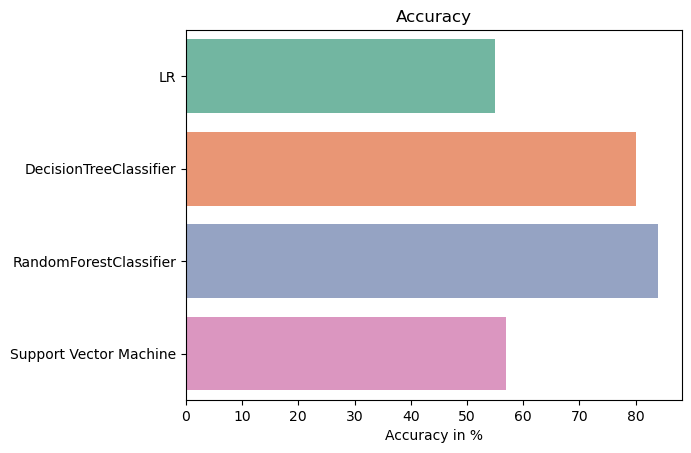

In [31]:
sns.barplot(x=Accuracy, y=models, palette="Set2")
plt.xlabel('Accuracy in %')
plt.title('Accuracy')
plt.show()

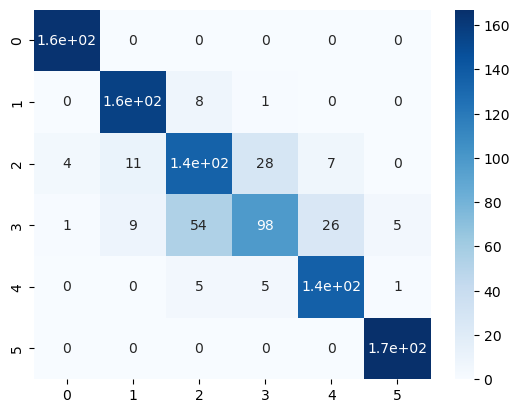

In [32]:
# get confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, model_RF.predict(x_test))
sns.heatmap(confusion_matrix (y_test , model_RF.predict(x_test)), cmap='Blues', annot = True)
plt.show()

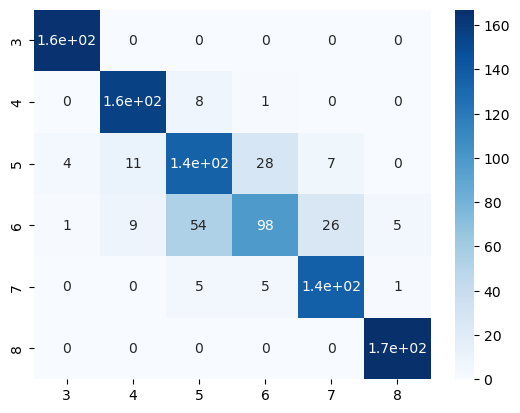

In [ ]:
# confusion matrix on random forest
labels=[3,4,5,6,7,8]
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, model_RF.predict(x_test), labels=[3,4,5,6,7,8])
sns.heatmap(confusion_matrix(y_test, model_RF.predict(x_test)), 
            cmap='Blues', annot=True, xticklabels=labels, yticklabels=labels)
plt.show()

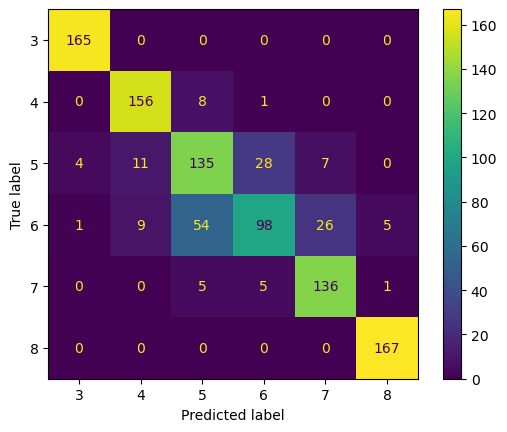

In [34]:
# confusion matrix diaplay
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, model_RF.predict(x_test))
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model_RF.classes_)
cm_display.plot()
plt.show()

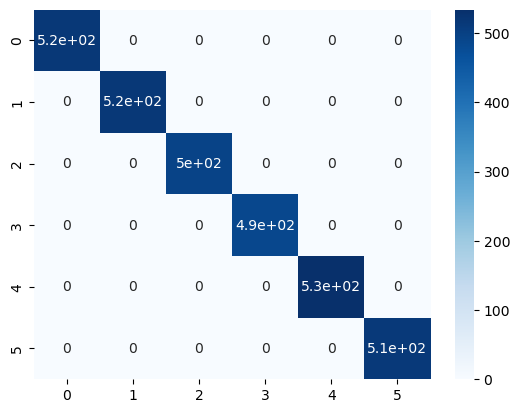

In [35]:
#confusion matrix on training data
from sklearn.metrics import confusion_matrix    
confusion_matrix(y_train,model_RF.predict(x_train))
sns.heatmap(confusion_matrix(y_train,model_RF.predict(x_train)), annot=True , cmap='Blues')
plt.show()

In [36]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [37]:
#use RF model for prediction on user input
# list of features names in  columns
feature_names = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']
#create a dictionary to map features to values
feature_values ={
    'fixed acidity': 7.4,
    'volatile acidity': 0.70,
    'citric acid': 0.00,
    'residual sugar': 0.641854,
    'chlorides': -2.57022,
    'free sulfur dioxide': 0.56093,
    'total sulfur dioxide': 0.67851,
    'density': 0.4523,
    'pH': 3.51,
    'sulphates': 0.56,
    'alcohol': 9.4
}
# create a dataframe with user input    
user_input = pd.DataFrame([feature_values],columns=feature_names)
# scaler
user_input = scaler.transform(user_input)
# make the prediction
prediction = model_RF.predict(user_input)
# print the prediction
print(f'The predicted quality of wine is: {prediction}')

The predicted quality of wine is: [5]


In [38]:

# save Random forest model
import pickle
pickle.dump(model_RF, open('model_RF.pkl', 'wb'))

In [39]:
#save scaler
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))